# Ultra-Lightweight Arrhythmia Detection Starter Notebook

This notebook is a **starting pipeline** for the project:

**MIT-BIH ECG data → preprocessing/windowing → baseline 1D-CNN → pruning → INT8 quantization → benchmark**

Goal: get a working baseline first, then add compression and deployment steps.

## 0. Install dependencies

Run once in a fresh environment. Skip if already installed.

In [24]:
# Install tf_keras to provide legacy Keras 2 support for TFMOT
!pip install numpy pandas matplotlib scipy scikit-learn wfdb tensorflow tensorflow-model-optimization tf_keras

## 1. Imports and configuration

In [25]:
import os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import wfdb
import tensorflow as tf
from tensorflow.keras import layers, models
warnings.filterwarnings("ignore")
print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.19.0
Num GPUs: 1


In [26]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Start small for debugging; expand later.
RECORDS = ['100','101','102','103','104','105','106','107','108','109']
WINDOW_SIZE = 256
HALF_WINDOW = WINDOW_SIZE // 2
TARGET_LEAD = 0

# Binary starter labels: 0 = normal, 1 = arrhythmia
NORMAL_SYMBOLS = {'N'}
ARRHYTHMIA_SYMBOLS = {'L','R','A','a','J','S','V','E','F','/','f','j','e'}

BATCH_SIZE = 64
EPOCHS = 10
VALIDATION_SIZE = 0.2
TEST_SIZE = 0.2

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

## 2. Load MIT-BIH records

This uses `wfdb` to stream records from PhysioNet. Internet access is required the first time.

In [27]:
def load_mitbih_record(record_id, pn_dir='mitdb'):
    # Load ECG signal and annotations for one MIT-BIH record.
    record = wfdb.rdrecord(record_id, pn_dir=pn_dir)
    ann = wfdb.rdann(record_id, 'atr', pn_dir=pn_dir)
    signal = record.p_signal[:, TARGET_LEAD].astype(np.float32)
    fs = record.fs
    return signal, ann.sample, ann.symbol, fs

signal, r_peaks, symbols, fs = load_mitbih_record(RECORDS[0])
print("Record:", RECORDS[0])
print("Signal shape:", signal.shape)
print("Sampling frequency:", fs)
print("First 10 annotations:", list(zip(r_peaks[:10], symbols[:10])))

Record: 100
Signal shape: (650000,)
Sampling frequency: 360
First 10 annotations: [(18, '+'), (77, 'N'), (370, 'N'), (662, 'N'), (946, 'N'), (1231, 'N'), (1515, 'N'), (1809, 'N'), (2044, 'A'), (2402, 'N')]


## 3. Visualize a raw ECG segment

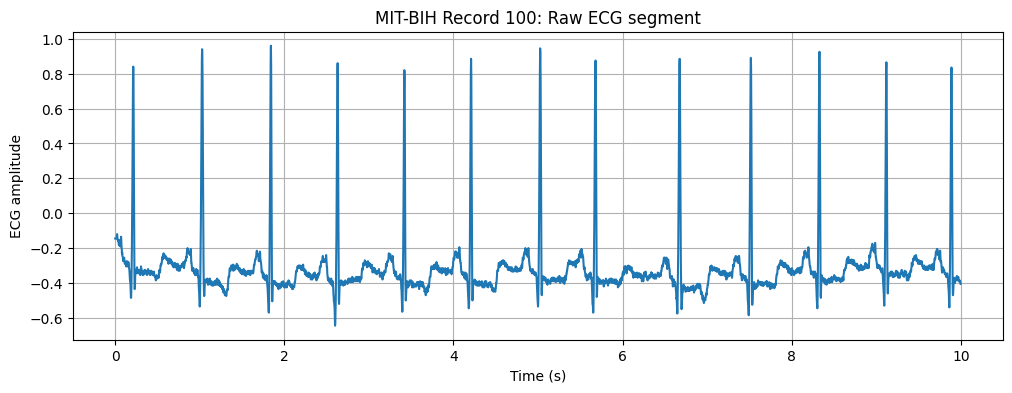

In [28]:
plt.figure(figsize=(12, 4))
start = 0
end = min(len(signal), fs * 10)
plt.plot(np.arange(start, end) / fs, signal[start:end])
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.title(f"MIT-BIH Record {RECORDS[0]}: Raw ECG segment")
plt.grid(True)
plt.show()

## 4. Preprocessing: filtering, normalization, and beat-window extraction

Starter preprocessing:
1. Bandpass filter ECG signal.
2. Normalize each full record.
3. Around each annotated beat, crop a fixed-length window.
4. Convert annotation symbols to binary labels.

In [29]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

def normalize_signal(signal, eps=1e-8):
    return ((signal - np.mean(signal)) / (np.std(signal) + eps)).astype(np.float32)

def symbol_to_binary_label(symbol):
    if symbol in NORMAL_SYMBOLS:
        return 0
    if symbol in ARRHYTHMIA_SYMBOLS:
        return 1
    return None

def extract_windows_from_record(record_id):
    signal, r_peaks, symbols, fs = load_mitbih_record(record_id)
    signal = normalize_signal(bandpass_filter(signal, fs))
    X, y = [], []
    for peak, sym in zip(r_peaks, symbols):
        label = symbol_to_binary_label(sym)
        if label is None:
            continue
        left, right = peak - HALF_WINDOW, peak + HALF_WINDOW
        if left < 0 or right > len(signal):
            continue
        window = signal[left:right]
        if len(window) != WINDOW_SIZE:
            continue
        X.append(window)
        y.append(label)
    return np.asarray(X, dtype=np.float32)[..., np.newaxis], np.asarray(y, dtype=np.int64)

In [31]:
import time

all_X, all_y, record_counts = [], [], []
MAX_RETRIES = 3

for rec in RECORDS:
    success = False
    for i in range(MAX_RETRIES):
        try:
            X_rec, y_rec = extract_windows_from_record(rec)
            all_X.append(X_rec)
            all_y.append(y_rec)
            record_counts.append({
                "record": rec,
                "num_windows": len(y_rec),
                "normal": int(np.sum(y_rec == 0)),
                "arrhythmia": int(np.sum(y_rec == 1)),
            })
            success = True
            break
        except Exception as e:
            print(f"Error loading record {rec} (Attempt {i+1}/{MAX_RETRIES}): {e}")
            if i < MAX_RETRIES - 1:
                time.sleep(2)  # Wait before retrying

    if not success:
        print(f"Failed to load record {rec} after {MAX_RETRIES} attempts. Skipping...")

if all_X:
    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    display(pd.DataFrame(record_counts))
    print("Overall class counts:", dict(zip(*np.unique(y, return_counts=True))))
else:
    print("No records were loaded. Please check your internet connection or PhysioNet status.")

Error loading record 100 (Attempt 1/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/
Error loading record 102 (Attempt 1/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/
Error loading record 104 (Attempt 1/3): 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/104.hea
Error loading record 104 (Attempt 2/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Error loading record 104 (Attempt 3/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Failed to load record 104 after 3 attempts. Skipping...
Error loading record 105 (Attempt 1/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/
Error loading record 106 (Attempt 1/3): 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/106.atr
Error loading record 106 (Attempt 2/3): 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Error loading record 107 (Attemp

,record,num_windows,normal,arrhythmia
0,100,2271,2237,34
1,101,1862,1859,3
2,102,2187,99,2088
3,103,2083,2081,2
4,105,2567,2526,41
5,106,2027,1507,520
6,108,1762,1738,24
7,109,2530,0,2530


Overall class counts: {0: 12047, 1: 5242}


## 5. Visualize sample windows

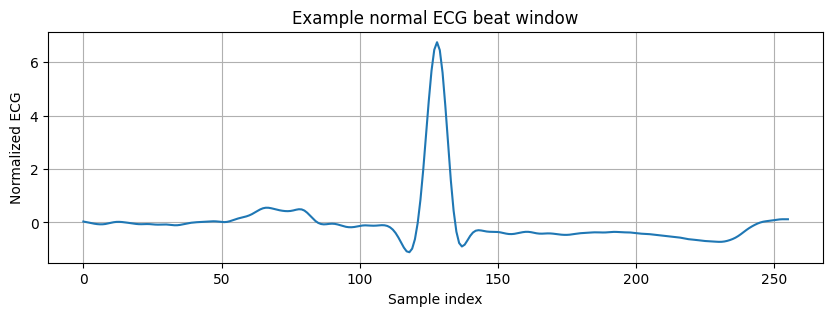

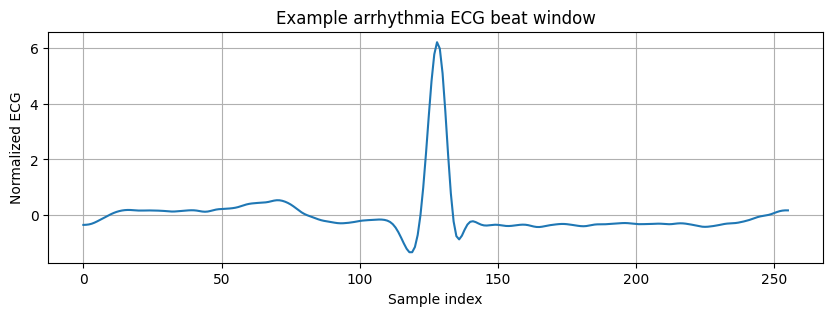

In [32]:
def plot_sample_window(label_value, title):
    idxs = np.where(y == label_value)[0]
    if len(idxs) == 0:
        print(f"No samples for label {label_value}")
        return
    idx = idxs[0]
    plt.figure(figsize=(10, 3))
    plt.plot(X[idx, :, 0])
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Normalized ECG")
    plt.grid(True)
    plt.show()

plot_sample_window(0, "Example normal ECG beat window")
plot_sample_window(1, "Example arrhythmia ECG beat window")

## 6. Train/validation/test split

For a stronger experiment, split by patient/record rather than random beat windows. This starter uses random split for simplicity.

In [33]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=VALIDATION_SIZE, random_state=SEED, stratify=y_trainval)
print("Train:", X_train.shape, dict(zip(*np.unique(y_train, return_counts=True))))
print("Val:  ", X_val.shape, dict(zip(*np.unique(y_val, return_counts=True))))
print("Test: ", X_test.shape, dict(zip(*np.unique(y_test, return_counts=True))))

Train: (11064, 256, 1) {0: 7709, 1: 3355}
Val:   (2767, 256, 1) {0: 1928, 1: 839}
Test:  (3458, 256, 1) {0: 2410, 1: 1048}


## 7. Build baseline 1D-CNN

In [34]:
def build_baseline_1dcnn(input_shape=(WINDOW_SIZE, 1), num_classes=2):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(16, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_1dcnn()
baseline_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 256, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 128, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 64, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,490 (44.88 KB)

 Trainable params: 11,266 (44.01 KB)

 Non-trainable params: 224 (896.00 B)

In [35]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
history = baseline_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)

Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9361 - loss: 0.2121 - val_accuracy: 0.8580 - val_loss: 0.5368
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9844 - loss: 0.0625 - val_accuracy: 0.6906 - val_loss: 0.6313
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0424 - val_accuracy: 0.9624 - val_loss: 0.0990
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0355 - val_accuracy: 0.9910 - val_loss: 0.0340
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9911 - loss: 0.0297 - val_accuracy: 0.9845 - val_loss: 0.0491
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9927 - loss: 0.0268 - val_accuracy: 0.9888 - val_loss: 0.0411
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9937 - loss: 0.0234 - val_accuracy: 0.9902 - val_loss: 0.0385


## 8. Evaluate baseline model

In [36]:
def evaluate_keras_model(model, X_eval, y_eval, name="model"):
    probs = model.predict(X_eval, batch_size=BATCH_SIZE, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_eval, preds)
    print(f"{name} accuracy: {acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_eval, preds, target_names=['normal', 'arrhythmia']))
    print("Confusion matrix:")
    print(confusion_matrix(y_eval, preds))
    return acc

baseline_acc = evaluate_keras_model(baseline_model, X_test, y_test, name="Baseline FP32 1D-CNN")

Baseline FP32 1D-CNN accuracy: 0.9928

Classification report:
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99      2410
  arrhythmia       0.99      0.98      0.99      1048

    accuracy                           0.99      3458
   macro avg       0.99      0.99      0.99      3458
weighted avg       0.99      0.99      0.99      3458

Confusion matrix:
[[2403    7]
 [  18 1030]]


In [37]:
baseline_path = ARTIFACT_DIR / "baseline_1dcnn.keras"
baseline_model.save(baseline_path)
print("Saved:", baseline_path)
print("File size KB:", baseline_path.stat().st_size / 1024)

Saved: artifacts/baseline_1dcnn.keras
File size KB: 194.0302734375


## 9. Baseline latency benchmark

In [38]:
def benchmark_keras_latency(model, sample, num_runs=200, warmup=20):
    sample = sample.astype(np.float32)
    for _ in range(warmup):
        _ = model.predict(sample, verbose=0)
    start = time.perf_counter()
    for _ in range(num_runs):
        _ = model.predict(sample, verbose=0)
    end = time.perf_counter()
    return (end - start) * 1000 / num_runs

sample = X_test[:1]
baseline_latency_ms = benchmark_keras_latency(baseline_model, sample)
print(f"Baseline average latency: {baseline_latency_ms:.3f} ms/sample")

Baseline average latency: 72.045 ms/sample


## 10. Pruning

This uses TensorFlow Model Optimization Toolkit pruning. It is a practical compression baseline.

In [39]:
try:
    import tensorflow_model_optimization as tfmot
    TFMOT_AVAILABLE = True
except Exception as e:
    print("tensorflow-model-optimization not available:", e)
    TFMOT_AVAILABLE = False

In [40]:
if TFMOT_AVAILABLE:
    import tf_keras
    import tensorflow_model_optimization as tfmot

    # Use tf_keras (Legacy Keras 2) to ensure compatibility with tfmot
    def build_legacy_1dcnn(input_shape=(WINDOW_SIZE, 1), num_classes=2):
        model = tf_keras.Sequential([
            tf_keras.layers.InputLayer(input_shape=input_shape),
            tf_keras.layers.Conv1D(16, kernel_size=5, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.MaxPooling1D(pool_size=2),
            tf_keras.layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.MaxPooling1D(pool_size=2),
            tf_keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.GlobalAveragePooling1D(),
            tf_keras.layers.Dense(32, activation='relu'),
            tf_keras.layers.Dropout(0.2),
            tf_keras.layers.Dense(num_classes, activation='softmax')
        ])
        return model

    prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

    # Create model using legacy Keras
    base_model_for_pruning = build_legacy_1dcnn()

    steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
    end_step = steps_per_epoch * max(1, EPOCHS // 2)
    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=0.50,
            begin_step=0,
            end_step=end_step
        )
    }

    # Apply pruning to the legacy model
    pruned_model = prune_low_magnitude(base_model_for_pruning, **pruning_params)

    pruned_model.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    pruning_callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tf_keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    ]

    pruned_history = pruned_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=pruning_callbacks,
        verbose=1
    )

    stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    # Note: stripped_pruned_model is a tf_keras model
    stripped_pruned_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    stripped_pruned_model = None

Epoch 1/10
173/173 [==============================] - 10s 14ms/step - loss: 0.1927 - accuracy: 0.9487 - val_loss: 1.0003 - val_accuracy: 0.3083
Epoch 2/10
173/173 [==============================] - 2s 11ms/step - loss: 0.0746 - accuracy: 0.9788 - val_loss: 4.0227 - val_accuracy: 0.3032
Epoch 3/10
173/173 [==============================] - 4s 25ms/step - loss: 0.0620 - accuracy: 0.9824 - val_loss: 0.5871 - val_accuracy: 0.7282
Epoch 4/10
173/173 [==============================] - 5s 29ms/step - loss: 0.0444 - accuracy: 0.9881 - val_loss: 0.0372 - val_accuracy: 0.9888
Epoch 5/10
173/173 [==============================] - 3s 18ms/step - loss: 0.0355 - accuracy: 0.9909 - val_loss: 0.0384 - val_accuracy: 0.9895
Epoch 6/10
173/173 [==============================] - 2s 11ms/step - loss: 0.0292 - accuracy: 0.9915 - val_loss: 0.0257 - val_accuracy: 0.9939
Epoch 7/10
173/173 [==============================] - 2s 11ms/step - loss: 0.0274 - accuracy: 0.9927 - val_loss: 0.0276 - val_accuracy: 0.992

In [41]:
if stripped_pruned_model is not None:
    pruned_acc = evaluate_keras_model(stripped_pruned_model, X_test, y_test, name="Pruned 1D-CNN")
    pruned_path = ARTIFACT_DIR / "pruned_1dcnn.keras"
    stripped_pruned_model.save(pruned_path)
    pruned_latency_ms = benchmark_keras_latency(stripped_pruned_model, sample)
    print("Saved:", pruned_path)
    print("Pruned model size KB:", pruned_path.stat().st_size / 1024)
    print(f"Pruned average latency: {pruned_latency_ms:.3f} ms/sample")
else:
    pruned_acc = None
    pruned_latency_ms = None

Pruned 1D-CNN accuracy: 0.9948

Classification report:
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      2410
  arrhythmia       1.00      0.99      0.99      1048

    accuracy                           0.99      3458
   macro avg       1.00      0.99      0.99      3458
weighted avg       0.99      0.99      0.99      3458

Confusion matrix:
[[2406    4]
 [  14 1034]]
Saved: artifacts/pruned_1dcnn.keras
Pruned model size KB: 87.4638671875
Pruned average latency: 56.678 ms/sample


## 11. TFLite INT8 quantization

This converts the pruned model to INT8 TFLite. If pruning is skipped, it converts the baseline model.

In [42]:
def representative_dataset():
    n = min(200, len(X_train))
    for i in range(n):
        yield [X_train[i:i+1].astype(np.float32)]

source_model_for_tflite = stripped_pruned_model if stripped_pruned_model is not None else baseline_model
converter = tf.lite.TFLiteConverter.from_keras_model(source_model_for_tflite)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()
tflite_path = ARTIFACT_DIR / "ecg_1dcnn_pruned_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_int8_model)
print("Saved:", tflite_path)
print("TFLite INT8 size KB:", tflite_path.stat().st_size / 1024)

Saved: artifacts/ecg_1dcnn_pruned_int8.tflite
TFLite INT8 size KB: 25.0078125


## 12. Evaluate TFLite INT8 model

In [43]:
def evaluate_tflite_int8(tflite_model_path, X_eval, y_eval):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    preds = []
    for x in X_eval:
        x = x[np.newaxis, ...].astype(np.float32)
        if input_details['dtype'] == np.int8:
            x_q = np.round(x / input_scale + input_zero_point).astype(np.int8)
        else:
            x_q = x.astype(input_details['dtype'])
        interpreter.set_tensor(input_details['index'], x_q)
        interpreter.invoke()
        y_q = interpreter.get_tensor(output_details['index'])
        if output_details['dtype'] == np.int8:
            y_float = (y_q.astype(np.float32) - output_zero_point) * output_scale
        else:
            y_float = y_q
        preds.append(int(np.argmax(y_float, axis=1)[0]))
    preds = np.asarray(preds)
    acc = accuracy_score(y_eval, preds)
    print(f"TFLite INT8 accuracy: {acc:.4f}")
    print(classification_report(y_eval, preds, target_names=['normal', 'arrhythmia']))
    print(confusion_matrix(y_eval, preds))
    return acc

int8_acc = evaluate_tflite_int8(tflite_path, X_test, y_test)

TFLite INT8 accuracy: 0.8965
              precision    recall  f1-score   support

      normal       0.87      1.00      0.93      2410
  arrhythmia       1.00      0.66      0.79      1048

    accuracy                           0.90      3458
   macro avg       0.93      0.83      0.86      3458
weighted avg       0.91      0.90      0.89      3458

[[2408    2]
 [ 356  692]]


In [44]:
def benchmark_tflite_latency(tflite_model_path, sample, num_runs=500, warmup=50):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    x = sample.astype(np.float32)
    if input_details['dtype'] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    else:
        x = x.astype(input_details['dtype'])
    for _ in range(warmup):
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    start = time.perf_counter()
    for _ in range(num_runs):
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    end = time.perf_counter()
    return (end - start) * 1000 / num_runs

int8_latency_ms = benchmark_tflite_latency(tflite_path, X_test[:1])
print(f"TFLite INT8 average latency: {int8_latency_ms:.3f} ms/sample")

TFLite INT8 average latency: 0.056 ms/sample


## 13. Final experiment table

Use this table in the final report/demo. Replace or extend it after running on Raspberry Pi / ESP32S3.

In [45]:
results = []
results.append({"model": "Baseline FP32 1D-CNN", "accuracy": baseline_acc, "size_kb": baseline_path.stat().st_size / 1024, "latency_ms_per_sample": baseline_latency_ms})
if stripped_pruned_model is not None:
    results.append({"model": "Pruned 1D-CNN", "accuracy": pruned_acc, "size_kb": pruned_path.stat().st_size / 1024, "latency_ms_per_sample": pruned_latency_ms})
results.append({"model": "Pruned + INT8 TFLite" if stripped_pruned_model is not None else "INT8 TFLite", "accuracy": int8_acc, "size_kb": tflite_path.stat().st_size / 1024, "latency_ms_per_sample": int8_latency_ms})
results_df = pd.DataFrame(results)
results_df

,model,accuracy,size_kb,latency_ms_per_sample
0,Baseline FP32 1D-CNN,0.992770,194.030273,72.044832
1,Pruned 1D-CNN,0.994795,87.463867,56.677683
2,Pruned + INT8 TFLite,0.896472,25.007812,0.056484


In [46]:
results_csv = ARTIFACT_DIR / "benchmark_results.csv"
results_df.to_csv(results_csv, index=False)
print("Saved:", results_csv)

Saved: artifacts/benchmark_results.csv


## 14. Next steps

1. Add more MIT-BIH records.
2. Try patient-wise train/test split.
3. Try multi-class labels instead of binary labels.
4. Run the `.tflite` model on Raspberry Pi 5 using `tf.lite.Interpreter`.
5. If time allows, convert the TFLite model to a C array for ESP32S3 / TFLite Micro.